In [1]:
#to prevent colab to automatically disconnect
import IPython
from google.colab import output

display(IPython.display.Javascript('''
 function ClickConnect(){
   btn = document.querySelector("colab-connect-button")
   if (btn != null){
     console.log("Click colab-connect-button");
     btn.click()
     }

   btn = document.getElementById('ok')
   if (btn != null){
     console.log("Click reconnect");
     btn.click()
     }
  }

setInterval(ClickConnect,60000)
'''))

print("Done.")

<IPython.core.display.Javascript object>

Done.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Step 1: Importing Libraries**

In [3]:
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

# For data processing
import math
from math import sqrt

# For data processing and manipulation
import matplotlib as mpl
%matplotlib inline

# For checking path
import os
import json
import joblib

#metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

#tensorflow libs
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping , Callback
import tensorflow as tf
from tensorflow.keras import backend as K
from keras import backend

from tensorflow.keras.layers import *
from tensorflow.keras.layers import Dense , GRU ,Dropout , PReLU , RepeatVector ,TimeDistributed, Attention,LayerNormalization,Add,Activation
from tensorflow.keras.models import Sequential,load_model,Model
from tensorflow.keras.utils import to_categorical , plot_model
from tensorflow.keras import regularizers, constraints, initializers, activations

from sklearn.linear_model import LinearRegression
import xgboost as xgb
from lightgbm import LGBMRegressor

from tensorflow.keras.layers import InputSpec

#from keras_self_attention import SeqSelfAttention
from tensorflow.keras.layers import Concatenate

from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional, TimeDistributed, LayerNormalization, Add
from tensorflow.keras import layers


tf.get_logger().setLevel('ERROR')
mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

In [4]:
np.random.seed(42)

# **Step 2: Loading Necessary Dataset, Files**

**2.1 Loading Result Files**

In [5]:
weighted_avg_path = r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/Results/DLF RESULTS/weighted_average.csv'
lr_result_path = r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/Results/DLF RESULTS/linear_regression.csv'
lgbm_result_path = r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/Results/DLF RESULTS/LGBM_Regressor.csv'

In [6]:
weighted_avg = pd.read_csv(weighted_avg_path)
lr_result = pd.read_csv(lr_result_path)
lgbm_result = pd.read_csv(lgbm_result_path)


In [7]:
best_strategies = pd.read_csv(r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/Results/best_strategies.csv')
best_strategies.head(21)

,Patrol Division,bigru_test_rmse,cnn_bigru_test_rmse,simple_avg_test_rmse,weighted_avg_test_rmse,lr_test_rmse,xgb_test_rmse,lgbm_test_rmse,Best Strategy
0,1,0.713613,0.734771,0.704967,0.703575,0.688575,0.672450,0.671789,LightGBM
1,2,0.403934,0.416581,0.400836,0.399779,0.398458,0.404401,0.404372,Linear Regression
2,3,0.363826,0.392695,0.349086,0.347180,0.349630,0.352477,0.363004,Weighted Avg
3,4,0.184826,0.186770,0.180188,0.180216,0.177243,0.183516,0.183662,Linear Regression
4,5,0.194903,0.206728,0.195044,0.193526,0.193351,0.201440,0.199924,Linear Regression
5,6,0.250244,0.264965,0.250983,0.248895,0.247907,0.248468,0.247694,LightGBM
6,7,0.227689,0.298715,0.245665,0.227689,0.222979,0.236334,0.235879,Linear Regression
7,8,0.202879,0.213828,0.203509,0.201931,0.202353,0.208317,0.208260,Weighted Avg
8,9,0.197093,0.209289,0.198030,0.196184,0.196297,0.202499,0.202054,Weighted Avg
9,10,0.200406,0.207974,0.199652,0.198842,0.198224,0.204508,0.204227,Linear Regression


In [8]:
weighted_avg.head()

,Patrol Division,best_bi_gru_weight,corresponding_cnn_bi_gru_weight,best_rmse,best_mae
0,1,0.6,0.4,0.703575,0.184667
1,2,0.7,0.3,0.399779,0.091154
2,3,0.6,0.4,0.347180,0.087599
3,4,0.6,0.4,0.180216,0.054463
4,5,0.8,0.2,0.193526,0.052026


In [9]:
lr_result.head()

,Division,test rmse,test mae
0,1,0.688575,0.192168
1,2,0.398458,0.098691
2,3,0.349630,0.098854
3,4,0.177243,0.054586
4,5,0.193351,0.057960


In [10]:
lgbm_result.head()

,Division,test rmse,test mae
0,1,0.671789,0.172391
1,2,0.404372,0.081332
2,3,0.363004,0.085849
3,4,0.183662,0.039952
4,5,0.199924,0.043802


**2.2 Loading Dataset**

In [11]:
dataset_path = r'/content/drive/MyDrive/Forecasting(without weather dataset)/2.Preparing Dataset to feed Model/patrol_wise_crime_dataset'
files = os.listdir(dataset_path)

In [12]:
#loading dataset
patrol_divisons = {}
dataset = {}
for file in files:
  name = file.split('_')[0]
  id = file.split('_')[1].split('.')[0]
  patrol_divisons[int(id)] = name
  dataset[int(id)] = pd.read_csv(os.path.join(dataset_path,file))
  if 'Unnamed: 0' in dataset[int(id)].columns:
        dataset[int(id)] = dataset[int(id)].drop('Unnamed: 0', axis=1)


patrol_divisons = dict(sorted(patrol_divisons.items()))
patrol_divisons

{1: 'Central',
 2: 'Rampart',
 3: 'Southwest',
 4: 'Hollenbeck',
 5: 'Harbor',
 6: 'Hollywood',
 7: 'Wilshire',
 8: 'West LA',
 9: 'Van Nuys',
 10: 'West Valley',
 11: 'Northeast',
 12: '77th Street',
 13: 'Newton',
 14: 'Pacific',
 15: 'N Hollywood',
 16: 'Foothill',
 17: 'Devonshire',
 18: 'Southeast',
 19: 'Mission',
 20: 'Olympic',
 21: 'Topanga'}

In [13]:
dataset[1].head()

,datetime,p_id,1,2,3,4,5,6,7,8,group 0,count,day sin,day cos,week sin,week cos,year sin,year cos
0,2010-01-01 00:00:00,1,6.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,0.0,11.0,-4.416858e-12,1.000000e+00,0.781831,0.623490,0.005161,0.999987
1,2010-01-01 03:00:00,1,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,3.0,7.071068e-01,7.071068e-01,0.846724,0.532032,0.007311,0.999973
2,2010-01-01 06:00:00,1,0.0,0.0,0.0,12.0,1.0,0.0,0.0,1.0,0.0,14.0,1.000000e+00,6.980203e-12,0.900969,0.433884,0.009461,0.999955
3,2010-01-01 09:00:00,1,2.0,0.0,0.0,13.0,1.0,0.0,1.0,0.0,0.0,17.0,7.071068e-01,-7.071068e-01,0.943883,0.330279,0.011612,0.999933
4,2010-01-01 12:00:00,1,0.0,2.0,0.0,7.0,0.0,0.0,0.0,1.0,0.0,10.0,9.543547e-12,-1.000000e+00,0.974928,0.222521,0.013762,0.999905


**2.3 Loading Models**

In [14]:
#Loading BI GRU Models
model_path = r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/Trained_model_Files/Multi Head Attention Bi GRU/mh_attn_bi_gru_model_files'
bi_gru_models = {}
for divison in patrol_divisons.keys():
  path = os.path.join(model_path,f"mh_attn_bi_gru_all_feature_{divison}.keras")
  bi_gru_models[divison] = load_model(path)

In [15]:
#Loading CNN BI GRU Models
model_path2 =r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/Trained_model_Files/Multi Head Attention CNN Bi GRU/mh_attn_cnn_bi_gru_model_files'
cnn_bi_gru_models = {}
for divison in patrol_divisons.keys():
  path = os.path.join(model_path2,f"mh_attn_cnn_bi_gru_{divison}.keras")
  cnn_bi_gru_models[divison] = load_model(path)

**Rename Columns**

In [16]:
weighted_avg.columns

Index(['Patrol Division', 'best_bi_gru_weight',
       'corresponding_cnn_bi_gru_weight', 'best_rmse', 'best_mae'],
      dtype='object')

In [17]:
lr_result.columns

Index(['Division', 'test rmse ', 'test mae '], dtype='object')

In [18]:
lgbm_result.columns

Index(['Division', 'test rmse ', 'test mae '], dtype='object')

In [19]:
weighted_Avg = weighted_avg.copy()
weighted_Avg.rename(columns={
    'best_rmse': 'weighted_avg_test_rmse',
    'best_mae': 'weighted_avg_test_mae'
}, inplace=True)
weighted_Avg.columns

Index(['Patrol Division', 'best_bi_gru_weight',
       'corresponding_cnn_bi_gru_weight', 'weighted_avg_test_rmse',
       'weighted_avg_test_mae'],
      dtype='object')

In [20]:
lr_result.rename(columns={'Division':'Patrol Division','test rmse ':'lr_test_rmse','test mae ':'lr_test_mae'},inplace = True)
lr_result.columns

Index(['Patrol Division', 'lr_test_rmse', 'lr_test_mae'], dtype='object')

In [21]:
lgbm_result.rename(columns={'Division':'Patrol Division','test rmse ':'lgbm_test_rmse','test mae ':'lgbm_test_mae'},inplace = True)
lgbm_result.columns

Index(['Patrol Division', 'lgbm_test_rmse', 'lgbm_test_mae'], dtype='object')

# **Step 3: Predicting  for 1 Divison for each Strategy**

In [22]:
patrol_divisons = {1: 'Central',2: 'Rampart', 3: 'Southwest', 4: 'Hollenbeck', 5: 'Harbor', 6: 'Hollywood', 7: 'Wilshire', 8: 'West LA', 9: 'Van Nuys',
 10: 'West Valley', 11: 'Northeast', 12: '77th Street', 13: 'Newton', 14: 'Pacific', 15: 'N Hollywood', 16: 'Foothill', 17: 'Devonshire', 18: 'Southeast', 19: 'Mission', 20: 'Olympic', 21: 'Topanga'}

In [23]:
models_path = {
    1 : r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/DLF_Models/lgbm_models/lgb_model_1.pkl',
    2 : r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/DLF_Models/lr_models/lr_model_2.pkl',
    3 : "Weighted Average",
    4 : r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/DLF_Models/lr_models/lr_model_4.pkl',
    5 : r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/DLF_Models/lr_models/lr_model_5.pkl',
    6 : r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/DLF_Models/lgbm_models/lgb_model_6.pkl',
    7 : r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/DLF_Models/lr_models/lr_model_7.pkl',
    8 : "Weighted Average",
    9 : "Weighted Average",
    10 : r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/DLF_Models/lr_models/lr_model_10.pkl',
    11 : r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/DLF_Models/lr_models/lr_model_11.pkl',
    12 : r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/Trained_model_Files/Multi Head Attention Bi GRU/mh_attn_bi_gru_model_files/mh_attn_bi_gru_all_feature_12.keras',
    13 : r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/Trained_model_Files/Multi Head Attention Bi GRU/mh_attn_bi_gru_model_files/mh_attn_bi_gru_all_feature_13.keras',
    14 : "Weighted Average",
    15 : r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/Trained_model_Files/Multi Head Attention Bi GRU/mh_attn_bi_gru_model_files/mh_attn_bi_gru_all_feature_15.keras',
    16 : r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/DLF_Models/lgbm_models/lgb_model_16.pkl',
    17 : r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/DLF/DLF_Models/lr_models/lr_model_17.pkl',
    18 : r'/content/drive/MyDrive/Forecasting(without weather dataset)/3.Crime Forecasting/Trained_model_Files/Multi Head Attention Bi GRU/mh_attn_bi_gru_model_files/mh_attn_bi_gru_all_feature_18.keras',
    19 : "Weighted Average",
    20 : "Weighted Average",
    21 : "Weighted Average"
}

**Utility Functions**

In [24]:
def train_test_val_split(dataset):
  columns_indices = {name:i for i,name in enumerate(dataset.columns)}
  n = len(dataset)

  #splitting dataset
  training_set = dataset[:int(n*0.7)]
  validation_set = dataset[int(n*0.7):int(n*0.9)]
  test_set = dataset[int(n*0.9):]

  num_features = dataset.shape[1]
  return training_set, validation_set, test_set, num_features, columns_indices

In [25]:
class WindowGenerator():

    def __init__(self, input_width, label_width, shift,
               train_df, val_df, test_df,
               label_columns=None , shuffle=False , batch_size = 64):
        '''
        The __init__ method includes all the necessary logic for the input and label indices.
        Input:
            input_width : input width / window size
            label_width : output width
            shift : size of window shifting forward
            train_df : train dataset
            val_df : validation dataset
            test_df : test dataset
            label_columns ( Default = None) : Label Columns
            shuffle ( Default = False) : weather to shuffle data
            batch_size (Default = 64) : Batch Size
        Output: None
        Example :
            w2 = WindowGenerator(input_width=6, label_width=1, shift=1,
                     label_columns=['count'])
            w2

        '''
        # Store the raw data.
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        self.shuffle = shuffle
        self.batch_size = batch_size

        # Work out the label column indices.
        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in
                                        enumerate(label_columns)}

        self.column_indices = {name: i for i, name in
                            enumerate(train_df.columns)}


        # Work out the window parameters.
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift

        self.input_slice = slice(0, input_width) #(start , stop)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.label_start = self.total_window_size - self.label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    def __repr__(self):
        return '\n'.join([
            f'Total window size: {self.total_window_size}',
            f'Input indices: {self.input_indices}',
            f'Label indices: {self.label_indices}',
            f'Label column name(s): {self.label_columns}'])

    def split_window(self, features):

        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]
        #taking only the labels that are presentin the label_columns
        if self.label_columns is not None:
            labels = tf.stack([labels[:, :, self.column_indices[name]] for name in self.label_columns],axis=-1)

        # Slicing doesn't preserve static shape information, so set the shapes
        # manually. This way the `tf.data.Datasets` are easier to inspect.
        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])

        return inputs, labels




    def make_dataset(self, data):

        data = np.array(data, dtype=np.float32)
        ds = tf.keras.preprocessing.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=self.shuffle,
            batch_size=self.batch_size,)
        ds = ds.map(self.split_window)
        return ds

    def create_dataset2(self , map_df , reshape=True):
      x = []
      y = []
      for res in iter(map_df):
        inputs, labels = res
        if(len(inputs)==64):
          x.append(inputs)
          y.append(labels)

      x = np.array(x)
      y = np.array(y)
      if(reshape):
        x = x.reshape(-1, x.shape[-2] , x.shape[-1])
        y = y.reshape(-1 , y.shape[-2] , y.shape[-1])
      return x , y


    @property
    def train(self):
        return self.make_dataset(self.train_df)

    @property
    def val(self):
        return self.make_dataset(self.val_df)

    @property
    def test(self):
        return self.make_dataset(self.test_df)



In [26]:
def create_data(train , test , val , columns):
    '''
    Create dataset from main train , test , val with given columns
    '''
    if(columns==None):
        columns = train.columns
    new_train = train[columns]
    new_test = test[columns]
    new_val = val[columns]
    return new_train , new_test , new_val

In [27]:
#without temperature
general_indexs = ['1', '2', '3', '4', '5', '6', '7','8', 'count',
           'day sin', 'day cos', 'week sin', 'week cos',
           'year sin', 'year cos', 'group 0']

x_col = ['day sin' , 'day cos' , 'year sin' , 'year cos' , 'week cos' , 'week sin' ,'datetime']

def generate_window(df_now, ret_test = 0):
    train_df , val_df , test_df , num_features_df , column_indices_df = train_test_val_split(df_now)
    train_df , test_df , val_df = create_data(train_df , test_df , val_df , general_indexs)
    y_col = []

    #storing label columns
    for i in train_df.columns:
        if (i in x_col):
            continue
        y_col.append(i)

    #creating window generator object
    wide_window_all = WindowGenerator(train_df=train_df, test_df=test_df , val_df=val_df,
        input_width=24, label_width=24, shift=1,
        label_columns=y_col)

    if (ret_test == 1):
      return wide_window_all, test_df
    else:
      return wide_window_all


Dataset Separation(For test and validation set)

In [28]:
def separate_datset(id):
  wide_window = generate_window(dataset[id])
  test_data = wide_window.test

      # Unbatch and convert test data to numpy arrays
  x_test, y_test = [], []
  for x, y in test_data.unbatch():
          x_test.append(x.numpy())
          y_test.append(y.numpy())
  x_test = np.array(x_test)
  y_test = np.array(y_test)

  return x_test,y_test

Make Dataframe

In [29]:
def make_dataframe(y_test,predicted):
      # Number of samples you want to inspect
      num_samples = 5

      # Create a list to store the comparison DataFrames
      comparison_list = []

      # Loop over the first `num_samples`
      for i in range(num_samples):
          true_vals = y_test[i]   # shape: (24, 10)
          pred_vals = predicted[i]   # shape: (24, 10)

          # Column names for better context
          columns = ['1','2','3','4','5','6','7','8','Count','Group 0']  # Adjust if needed

          df_true = pd.DataFrame(true_vals, columns=[f"Actual_{col}" for col in columns])
          df_pred = pd.DataFrame(pred_vals, columns=[f"Predicted_{col}" for col in columns])

          df_both = pd.concat([df_true, df_pred], axis=1)
          comparison_list.append(df_both)

      # Combine all comparisons into one DataFrame
      full_comparison= pd.concat(comparison_list, axis=0)

      # Reset index
      full_comparison.reset_index(drop=True, inplace=True)

      return full_comparison

# **Strategy 1: Weighted Average**

In [30]:
def weighted_Average(bi_gru_pred_1,cnn_bi_gru_pred_1,bigru_weights,cnn_bigru_weights):
  y_pred = ((bigru_weights * bi_gru_pred_1) + (cnn_bigru_weights * cnn_bi_gru_pred_1))
  return y_pred

In [31]:
indexs_wa = []
for key in models_path.keys():
  if models_path[key] == "Weighted Average":
    indexs_wa.append(key)

In [32]:
indexs_wa

[3, 8, 9, 14, 19, 20, 21]

In [33]:

id_1 = 8
bigru_weights = weighted_avg.loc[id_1,"best_bi_gru_weight"]
cnn_bigru_weights = weighted_avg.loc[id_1,"corresponding_cnn_bi_gru_weight"]
bi_gru_1 = bi_gru_models[id_1]
cnn_bi_gru_1 = cnn_bi_gru_models[id_1]

In [34]:
print(bigru_weights)
print(cnn_bigru_weights)

0.8
0.2


In [35]:
x_test_1,y_test_1 = separate_datset(id_1)

In [36]:
bi_gru_pred_1 = bi_gru_1.predict(x_test_1)
cnn_bi_gru_pred_1 = cnn_bi_gru_1.predict(x_test_1)

138/138 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step
138/138 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step


In [37]:
y_pred_1 = weighted_Average(bi_gru_pred_1,cnn_bi_gru_pred_1,bigru_weights,cnn_bigru_weights)

In [38]:
print("Prediction Shape :",y_pred_1.shape)
print("Test set Shape :",y_test_1.shape)

Prediction Shape : (4405, 24, 10)
Test set Shape : (4405, 24, 10)


In [39]:
#Flattening
y_pred_flat_1 = y_pred_1.reshape(-1)
y_test_flat_1 = y_test_1.reshape(-1)

rmse_1 = np.sqrt(mean_squared_error(y_test_flat_1, y_pred_flat_1))
mae_1 = mean_absolute_error(y_test_flat_1, y_pred_flat_1)

print(f"RMSE: {rmse_1}")
print(f"MAE : {mae_1}")


RMSE: 0.20193097485682987
MAE : 0.04486878260036013


In [40]:
full_comparison_1 = make_dataframe(y_test_1,y_pred_1)

In [41]:
full_comparison_1.head(10)

,Actual_1,Actual_2,Actual_3,Actual_4,Actual_5,Actual_6,Actual_7,Actual_8,Actual_Count,Actual_Group 0,Predicted_1,Predicted_2,Predicted_3,Predicted_4,Predicted_5,Predicted_6,Predicted_7,Predicted_8,Predicted_Count,Predicted_Group 0
0,1.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,5.0,0.0,0.971741,2.063506,0.000271,-0.009565,0.938822,0.995637,-0.000038,-0.010642,5.093754,-2.508000e-04
1,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,4.0,0.0,-0.027120,1.010686,0.000216,0.959999,0.948339,0.959683,0.000344,-0.007952,4.042389,-1.263063e-04
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.965488,-0.030777,0.000162,-0.056818,-0.010042,0.004325,0.000123,-0.003389,0.862617,7.121181e-05
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.029931,-0.025507,0.000086,0.917713,-0.003094,0.002649,0.000018,-0.001825,0.835627,1.631396e-04
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.015443,-0.015064,0.000159,0.962380,0.029816,0.028065,0.000007,-0.009730,0.993570,2.126973e-04
5,0.0,2.0,0.0,6.0,2.0,0.0,0.0,0.0,10.0,0.0,0.074424,2.012284,0.000418,6.135622,1.989408,0.023611,-0.000226,0.011005,10.373618,3.769102e-04
6,1.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,6.0,0.0,0.939668,0.969313,-0.000084,3.140830,-0.023719,-0.014506,0.001932,0.828984,6.138160,-5.860362e-04
7,0.0,1.0,0.0,2.0,1.0,0.0,0.0,0.0,4.0,0.0,-0.042649,0.998860,0.000432,2.024942,0.954260,0.002150,-0.000029,-0.007153,4.025219,5.411915e-07
8,3.0,0.0,0.0,3.0,0.0,1.0,0.0,0.0,7.0,0.0,3.071856,0.011905,0.000128,2.948010,0.004022,0.911042,0.000207,0.003415,7.048030,-1.165668e-04
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.022281,-0.003951,0.000261,-0.025026,-0.007197,0.004132,0.000240,0.000774,-0.026284,1.566750e-04


In [ ]:
# Step 1: Extract the last 24 records from your dataset
# Assuming `data` is your full scaled dataset with shape (N, 16)
# and `model` is your trained BiGRU model

last_24_input = x_test_1[-24:]  # shape: (24, 16)

# Step 2: Reshape to match model input shape (1 sample, 24 timesteps, 16 features)
last_24_input = np.expand_dims(last_24_input, axis=0)  # shape: (1, 24, 16)

# Step 3: Predict using the model
next_prediction = bigru_model.predict(last_24_input)

# Step 4: View result
print("Forecast for next time step:", next_prediction)


# **Strategy 2 :Linear Regression**

In [42]:
indexs_lr = []
for key in models_path.keys():
  if models_path[key] != "Weighted Average":
    path = models_path[key]
    model_folder = path.split('/')[-2]
    if  model_folder == "lr_models":
      indexs_lr.append(key)

In [43]:
indexs_lr

[2, 4, 5, 7, 10, 11, 17]

In [44]:
id_2 = 7
ml_model = joblib.load(models_path[id_2])
bi_gru = bi_gru_models[id_2]
cnn_bi_gru = cnn_bi_gru_models[id_2]

In [45]:
x_test_2,y_test_2 = separate_datset(id_2)

In [46]:
bi_gru_pred = bi_gru.predict(x_test_2)
cnn_bi_gru_pred = cnn_bi_gru.predict(x_test_2)

137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step


In [47]:
bi_gru_pred_reshaped = bi_gru_pred.reshape(-1)
cnn_bi_gru_pred_reshaped = cnn_bi_gru_pred.reshape(-1)
X_test_stack = np.column_stack((bi_gru_pred_reshaped, cnn_bi_gru_pred_reshaped))
lr_preds = ml_model.predict(X_test_stack)
y_test_reshaped = y_test_2.reshape(-1)

In [48]:
print("Prediction Shape :",lr_preds.shape)
print("Test Shape :",y_test_reshaped.shape)

Prediction Shape : (1046160,)
Test Shape : (1046160,)


In [49]:
rmse = np.sqrt(mean_squared_error(y_test_reshaped, lr_preds))
mae = mean_absolute_error(y_test_reshaped, lr_preds)

print(f"RMSE: {rmse}")
print(f"MAE : {mae}")


RMSE: 0.22297873483340572
MAE : 0.06947757303714752


In [50]:
original_shape = y_test_2.shape
y_test_original = y_test_reshaped.reshape(original_shape)
lr_preds_original = lr_preds.reshape(original_shape)

In [51]:
full_comparison_2 = make_dataframe(y_test_original,lr_preds_original)

In [52]:
full_comparison_2.head(10)

,Actual_1,Actual_2,Actual_3,Actual_4,Actual_5,Actual_6,Actual_7,Actual_8,Actual_Count,Actual_Group 0,Predicted_1,Predicted_2,Predicted_3,Predicted_4,Predicted_5,Predicted_6,Predicted_7,Predicted_8,Predicted_Count,Predicted_Group 0
0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.011946,1.986575,0.036163,0.014414,0.036147,0.033740,0.036159,0.031559,2.966583,0.036137
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.048466,0.017925,0.036328,1.020420,0.021584,0.028012,0.036324,0.029886,1.000597,0.036261
2,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,3.0,0.0,0.047013,0.016325,0.036345,2.015014,0.027818,0.992296,0.036557,0.034812,3.011322,0.036017
3,1.0,2.0,0.0,2.0,0.0,1.0,0.0,0.0,6.0,0.0,0.984122,1.968654,0.036128,2.043972,0.085575,0.963148,0.036070,0.027310,5.967411,0.036117
4,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,3.0,0.0,0.028777,0.028885,0.036302,2.987086,0.013385,0.024273,0.036485,0.035278,3.041691,0.036195
5,0.0,1.0,0.0,5.0,0.0,1.0,0.0,0.0,7.0,0.0,0.061853,0.978161,0.036460,4.882766,0.048040,0.902136,0.036519,0.018520,6.907338,0.036186
6,0.0,0.0,0.0,3.0,2.0,0.0,0.0,0.0,5.0,0.0,0.044761,0.065691,0.036461,2.983024,1.979409,0.045319,0.036224,0.031400,4.969297,0.036136
7,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.068042,0.046136,0.036659,0.081092,0.037526,0.038684,0.038310,0.031287,1.044035,0.036242
8,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,4.0,0.0,0.953403,1.012553,0.036148,1.908674,0.045629,0.066409,0.036004,0.030070,3.941917,0.036087
9,1.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,6.0,0.0,0.967881,0.056162,0.036310,4.060540,0.989283,0.030320,0.035880,0.032123,6.034706,0.036160


# **Strategy 3: LightGBM Regressor**

In [53]:
indexs_lgbm = []
for key in models_path.keys():
  if models_path[key] != "Weighted Average":
    path = models_path[key]
    model_folder = path.split('/')[-2]
    if  model_folder == "lgbm_models":
      indexs_lgbm.append(key)

In [54]:
indexs_lgbm

[1, 6, 16]

In [55]:
id_3 = 6
ml_model = joblib.load(models_path[id_3])
bi_gru = bi_gru_models[id_3]
cnn_bi_gru = cnn_bi_gru_models[id_3]

In [56]:
x_test_3,y_test_3 = separate_datset(id_3)

In [57]:
bi_gru_pred = bi_gru.predict(x_test_3)
cnn_bi_gru_pred = cnn_bi_gru.predict(x_test_3)

137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step


In [58]:
bi_gru_pred_reshaped = bi_gru_pred.reshape(-1)
cnn_bi_gru_pred_reshaped = cnn_bi_gru_pred.reshape(-1)
X_test_stack = np.column_stack((bi_gru_pred_reshaped, cnn_bi_gru_pred_reshaped))
lgbm_preds = ml_model.predict(X_test_stack)
y_test_reshaped = y_test_3.reshape(-1)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [59]:
print("Prediction Shape :",lgbm_preds.shape)
print("Test Shape :",y_test_reshaped.shape)

Prediction Shape : (1045920,)
Test Shape : (1045920,)


In [60]:
rmse = np.sqrt(mean_squared_error(y_test_reshaped, lgbm_preds))
mae = mean_absolute_error(y_test_reshaped, lgbm_preds)

print(f"RMSE: {rmse}")
print(f"MAE : {mae}")


RMSE: 0.2476937359637061
MAE : 0.07091198940177405


In [61]:
original_shape = y_test_3.shape
y_test_original = y_test_reshaped.reshape(original_shape)
lgbm_preds_original = lgbm_preds.reshape(original_shape)

In [62]:
full_comparison_3 = make_dataframe(y_test_original,lgbm_preds_original)

In [63]:
full_comparison_3.head(10)

,Actual_1,Actual_2,Actual_3,Actual_4,Actual_5,Actual_6,Actual_7,Actual_8,Actual_Count,Actual_Group 0,Predicted_1,Predicted_2,Predicted_3,Predicted_4,Predicted_5,Predicted_6,Predicted_7,Predicted_8,Predicted_Count,Predicted_Group 0
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.003638,0.000496,0.031795,0.000496,0.030153,0.049362,0.015805,0.000496,1.003638,0.029721
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.006831,0.000496,0.028528,1.003638,-0.006831,0.030153,0.013462,0.000496,1.003638,0.039811
2,1.0,0.0,0.0,2.0,2.0,1.0,1.0,0.0,7.0,0.0,1.003638,0.112391,0.225894,1.988138,1.988138,1.003638,0.066872,0.000496,6.416382,0.024718
3,1.0,1.0,0.0,2.0,1.0,1.0,0.0,1.0,7.0,0.0,1.003638,1.003638,0.086831,1.988138,1.003638,1.003638,0.066872,1.003638,6.927929,0.020546
4,1.0,0.0,0.0,2.0,2.0,0.0,0.0,1.0,6.0,0.0,1.003638,0.030153,0.086831,1.988138,1.988138,-0.006831,0.062327,1.003638,5.997158,0.034010
5,0.0,1.0,0.0,2.0,1.0,0.0,0.0,0.0,4.0,0.0,0.030153,1.003638,0.076430,1.988138,1.003638,0.030153,0.013462,-0.006831,4.020185,0.031795
6,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,4.0,0.0,0.000496,1.003638,0.225894,1.003638,1.003638,0.030153,0.132705,-0.006831,4.020185,0.024718
7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.0,0.0,0.049362,0.000496,0.029721,0.030153,-0.006831,1.003638,0.079266,1.003638,1.991536,0.039811
8,3.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,5.0,0.0,3.007507,0.112391,0.190722,0.112391,0.049362,1.003638,0.132705,0.000496,4.968550,0.024718
9,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,0.112391,0.000496,0.205504,1.003638,0.112391,0.030153,0.132705,0.000496,1.988138,0.029721


# **Strategy 4 :BI-GRU**

In [64]:
indexs_bigru = []
for key in models_path.keys():
  if models_path[key] != "Weighted Average":
    path = models_path[key]
    model_folder = path.split('/')[-2]
    if  model_folder == "mh_attn_bi_gru_model_files":
      indexs_bigru.append(key)

In [65]:
indexs_bigru

[12, 13, 15, 18]

In [66]:
id_4 = 12
bigru_model = load_model(models_path[id_4])

In [67]:
x_test_4 ,y_test_4 = separate_datset(id_4)

In [68]:
bigru_preds = bigru_model.predict(x_test_4)

138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step


In [69]:
y_test_4.shape

(4395, 24, 10)

In [70]:
bigru_preds.shape

(4395, 24, 10)

In [71]:
pred_reshape = bigru_preds.reshape(-1)
test_reshape = y_test_4.reshape(-1)
bigru_rmse = np.sqrt(mean_squared_error(test_reshape, pred_reshape))
bigru_mae = mean_absolute_error(test_reshape, pred_reshape)

print(f"RMSE: {bigru_rmse}")
print(f"MAE : {bigru_mae}")

RMSE: 0.2481671214564413
MAE : 0.05778684467077255


In [72]:
full_comparison_4 = make_dataframe(y_test_4,bigru_preds)

In [73]:
full_comparison_4.head(10)

,Actual_1,Actual_2,Actual_3,Actual_4,Actual_5,Actual_6,Actual_7,Actual_8,Actual_Count,Actual_Group 0,Predicted_1,Predicted_2,Predicted_3,Predicted_4,Predicted_5,Predicted_6,Predicted_7,Predicted_8,Predicted_Count,Predicted_Group 0
0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,1.0,1.005921,0.957281,0.000120,2.014585,-0.019847,-0.006563,0.002234,0.004714,4.886468,0.000637
1,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,5.0,0.0,1.983152,-0.036362,0.000522,0.051220,0.901371,0.011719,-0.000407,1.688335,5.007349,0.000292
2,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3.0,0.0,0.947782,-0.032793,-0.000198,0.053244,0.861371,0.864021,0.000291,-0.008685,2.840983,0.000208
3,4.0,0.0,0.0,2.0,5.0,0.0,0.0,0.0,11.0,0.0,3.889081,0.132434,-0.000020,2.092446,4.682103,-0.015641,0.000335,0.021831,10.768223,0.001661
4,2.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,4.0,0.0,2.031981,0.008481,-0.000176,0.989624,-0.020020,0.787898,-0.000300,0.003348,3.997253,0.000075
5,2.0,1.0,0.0,1.0,1.0,0.0,0.0,5.0,10.0,0.0,1.983569,0.992026,-0.001163,0.953892,1.145390,0.056259,0.007338,3.629414,9.478629,0.003591
6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.993249,-0.029158,0.000197,0.052209,0.008288,-0.001041,-0.000187,-0.007721,1.005422,-0.000011
7,2.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,4.0,0.0,1.993214,-0.009540,0.000026,0.986054,0.983306,-0.003994,-0.000214,-0.000210,3.970803,0.000025
8,2.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,5.0,0.0,1.875600,0.009701,0.000095,0.011242,2.948165,-0.008517,-0.000171,-0.000262,4.932669,0.000530
9,2.0,1.0,0.0,1.0,1.0,2.0,0.0,1.0,10.0,2.0,1.917627,0.769543,-0.000323,0.975865,1.033831,2.030242,0.010289,0.867303,9.896652,0.002006


# **Step 4 : Visualizing Prediction for Each Strategy**

**DOT PLOT**

In [74]:
def dot_plot(actual_count , predicted_count,id):


  plt.figure(figsize=(6,4))
  plt.scatter(range(1,11),actual_count,color="blue",label ="Actual",marker="o")
  plt.scatter(range(1,11),predicted_count,color ="red",label ="Predicted",marker="x")
  plt.title(f"Actual vs Predicted (Dot Plot) - For {patrol_divisons[id]}")
  plt.xlabel("Samples")
  plt.ylabel("Crime Count")
  plt.legend()
  plt.grid(False)

In [75]:
def residual_plot(actual_count,predicted_count,id):

  plt.figure(figsize=(6,4))
  residuals =  [a - p for a, p in zip(actual_count, predicted_count)]
  sn.scatterplot(x=predicted_count, y=residuals)
  plt.axhline(0, color='red', linestyle='--')
  plt.title(f'Residual Plot for {patrol_divisons[id]} ')
  plt.xlabel('Predicted')
  plt.ylabel('Residual (Actual - Predicted)')
  plt.show()

**For Strategy 1 :**

In [76]:
actual_count_1 = full_comparison_1["Actual_Count"].head(10)
predicted_count_1 = full_comparison_1["Predicted_Count"].head(10)

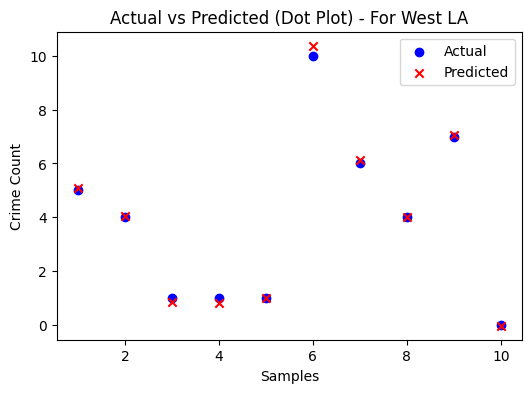

In [77]:
dot_plot(actual_count_1,predicted_count_1,id_1)

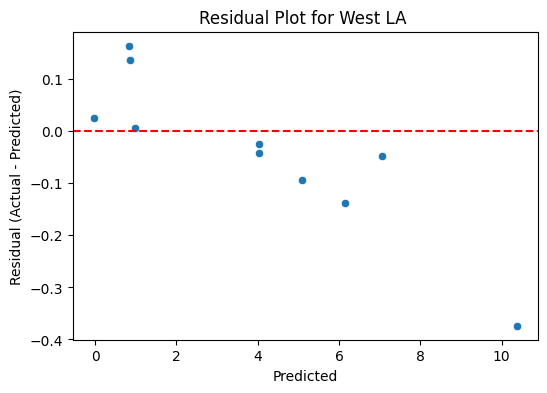

In [78]:
residual_plot(actual_count_1,predicted_count_1,id_1)

**For Strategy 2 :**

In [79]:
actual_count_2 = full_comparison_2["Actual_Count"].head(10)
predicted_count_2 = full_comparison_2["Predicted_Count"].head(10)

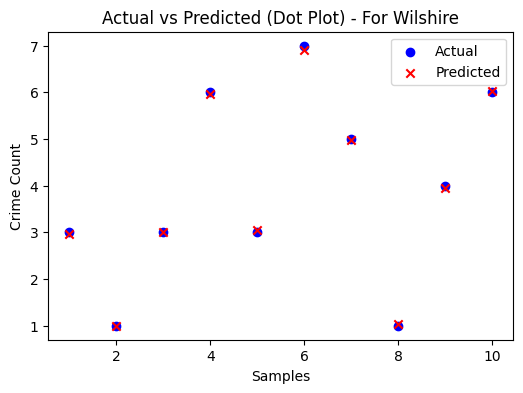

In [80]:
dot_plot(actual_count_2,predicted_count_2,id_2)

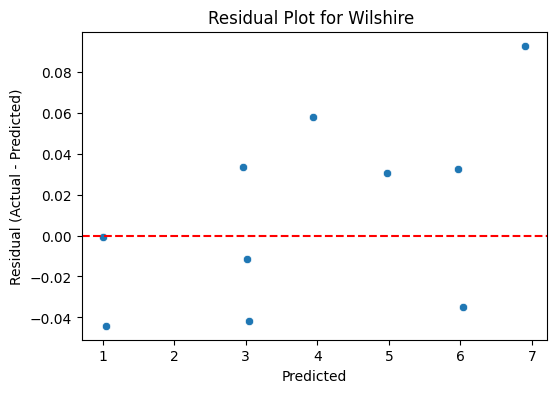

In [81]:
residual_plot(actual_count_2,predicted_count_2,id_2)

**For Strategy 3 :**

In [82]:
actual_count_3 = full_comparison_3["Actual_Count"].head(10)
predicted_count_3 = full_comparison_3["Predicted_Count"].head(10)


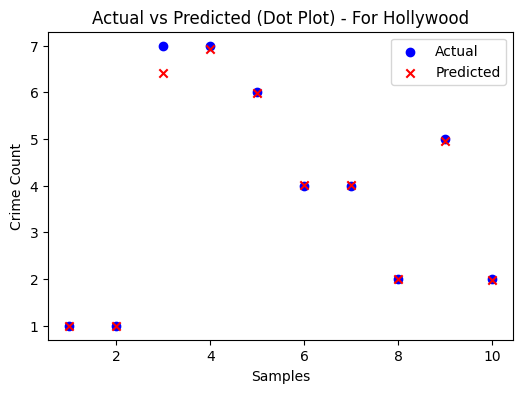

In [83]:
dot_plot(actual_count_3,predicted_count_3,id_3)

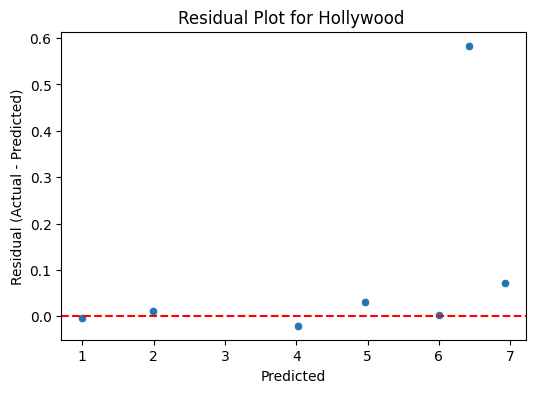

In [84]:
residual_plot(actual_count_3,predicted_count_3,id_3)

**For Strategy 4 :**

In [85]:
actual_count_4 = full_comparison_4["Actual_Count"].head(10)
predicted_count_4 = full_comparison_4["Predicted_Count"].head(10)


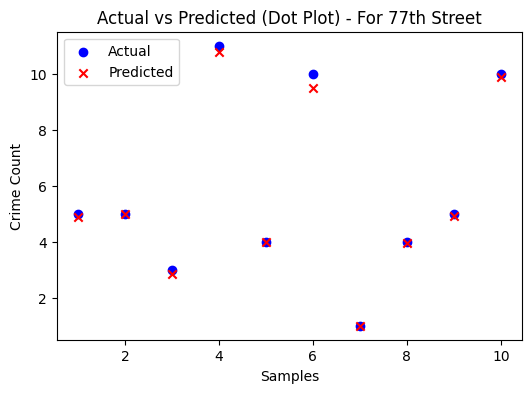

In [86]:
dot_plot(actual_count_4,predicted_count_4,id_4)

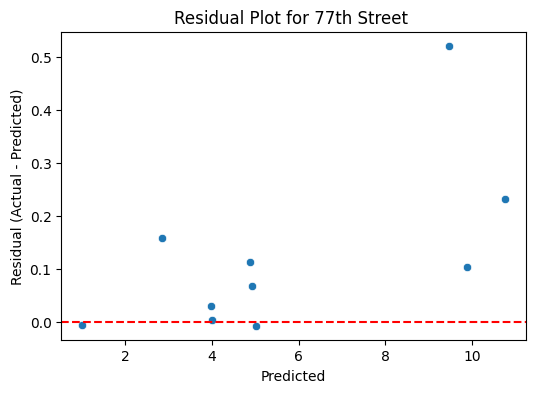

In [87]:
residual_plot(actual_count_4,predicted_count_4,id_4)